In [81]:
# Cell 1: Import Required Libraries
import pandas as pd
import numpy as np
import plotly.express as px
from datetime import timedelta
from matplotlib import pyplot as plt
from helpermodules import memory_handling as mh
import random
import requests

In [39]:
# Cell 2: Load the preprocessed data
pickle_helper = mh.PickleHelper.pickle_load('fedspeeches_preprocessed')
speeches_df = pickle_helper.obj
speeches_df

,date,speaker,title,link,text,timestamp,text_by_minute
0,2006-12-15,Chairman Ben S. Bernanke,The Chinese Economy: Progress and Challenges,/newsevents/speech/bernanke20061215a.htm,The emergence of China as a global economic po...,2006-12-15 10:00:00-05:00,The emergence of China as a global economic po...
1,2006-12-15,Chairman Ben S. Bernanke,The Chinese Economy: Progress and Challenges,/newsevents/speech/bernanke20061215a.htm,The emergence of China as a global economic po...,2006-12-15 10:01:00-05:00,"had reached seventy-one years, the infant mort..."
2,2006-12-15,Chairman Ben S. Bernanke,The Chinese Economy: Progress and Challenges,/newsevents/speech/bernanke20061215a.htm,The emergence of China as a global economic po...,2006-12-15 10:02:00-05:00,progress: Markets and productivityEconomists a...
3,2006-12-15,Chairman Ben S. Bernanke,The Chinese Economy: Progress and Challenges,/newsevents/speech/bernanke20061215a.htm,The emergence of China as a global economic po...,2006-12-15 10:03:00-05:00,"but steadily, away from central planning and t..."
4,2006-12-15,Chairman Ben S. Bernanke,The Chinese Economy: Progress and Challenges,/newsevents/speech/bernanke20061215a.htm,The emergence of China as a global economic po...,2006-12-15 10:04:00-05:00,information about supply and demand conditions...
...,...,...,...,...,...,...,...
24310,2024-01-08,Governor Michelle W. Bowman,New Year’s Resolutions for Bank Regulatory Pol...,/newsevents/speech/bowman20240108a.htm,It is a pleasure to join you this afternoon fo...,2024-01-08 10:24:00-05:00,"the requirements are spelled out in public, in..."
24311,2024-01-08,Governor Michelle W. Bowman,New Year’s Resolutions for Bank Regulatory Pol...,/newsevents/speech/bowman20240108a.htm,It is a pleasure to join you this afternoon fo...,2024-01-08 10:25:00-05:00,assumptions. Transparency allows bankers to un...
24312,2024-01-08,Governor Michelle W. Bowman,New Year’s Resolutions for Bank Regulatory Pol...,/newsevents/speech/bowman20240108a.htm,It is a pleasure to join you this afternoon fo...,2024-01-08 10:26:00-05:00,"standards. To the contrary, it means that we s..."
24313,2024-01-08,Governor Michelle W. Bowman,New Year’s Resolutions for Bank Regulatory Pol...,/newsevents/speech/bowman20240108a.htm,It is a pleasure to join you this afternoon fo...,2024-01-08 10:27:00-05:00,"this process, by sharing your views and concer..."


In [40]:
# Cell 3: Load Governors List
# Load the list of governors from a .txt file
with open("speakers.txt", "r") as f:
    governors = eval(f.read())  # Assuming the file contains a Python list

# Filter speeches by governors
filtered_speeches = speeches_df[speeches_df['speaker'].isin(governors)]
print(f"Number of speeches by governors: {len(filtered_speeches)}")
filtered_speeches

Number of speeches by governors: 10971


,date,speaker,title,link,text,timestamp,text_by_minute
0,2006-12-15,Chairman Ben S. Bernanke,The Chinese Economy: Progress and Challenges,/newsevents/speech/bernanke20061215a.htm,The emergence of China as a global economic po...,2006-12-15 10:00:00-05:00,The emergence of China as a global economic po...
1,2006-12-15,Chairman Ben S. Bernanke,The Chinese Economy: Progress and Challenges,/newsevents/speech/bernanke20061215a.htm,The emergence of China as a global economic po...,2006-12-15 10:01:00-05:00,"had reached seventy-one years, the infant mort..."
2,2006-12-15,Chairman Ben S. Bernanke,The Chinese Economy: Progress and Challenges,/newsevents/speech/bernanke20061215a.htm,The emergence of China as a global economic po...,2006-12-15 10:02:00-05:00,progress: Markets and productivityEconomists a...
3,2006-12-15,Chairman Ben S. Bernanke,The Chinese Economy: Progress and Challenges,/newsevents/speech/bernanke20061215a.htm,The emergence of China as a global economic po...,2006-12-15 10:03:00-05:00,"but steadily, away from central planning and t..."
4,2006-12-15,Chairman Ben S. Bernanke,The Chinese Economy: Progress and Challenges,/newsevents/speech/bernanke20061215a.htm,The emergence of China as a global economic po...,2006-12-15 10:04:00-05:00,information about supply and demand conditions...
...,...,...,...,...,...,...,...
15708,2017-04-04,Governor Daniel K. Tarullo,Departing Thoughts,/newsevents/speech/tarullo20170404a.htm,Tomorrow is my last day at the Federal Reserve...,2017-04-04 10:52:00-04:00,giving the firms the model will likely encoura...
15709,2017-04-04,Governor Daniel K. Tarullo,Departing Thoughts,/newsevents/speech/tarullo20170404a.htm,Tomorrow is my last day at the Federal Reserve...,2017-04-04 10:53:00-04:00,"model in the hands of the GSEs, even a scenari..."
15710,2017-04-04,Governor Daniel K. Tarullo,Departing Thoughts,/newsevents/speech/tarullo20170404a.htm,Tomorrow is my last day at the Federal Reserve...,2017-04-04 10:54:00-04:00,some granularity in the definition of asset ca...
15711,2017-04-04,Governor Daniel K. Tarullo,Departing Thoughts,/newsevents/speech/tarullo20170404a.htm,Tomorrow is my last day at the Federal Reserve...,2017-04-04 10:55:00-04:00,have liked to touch upon important topics such...


In [41]:
# Step 1: Ensure the timestamp column is in datetime format (if it's not already)

df = filtered_speeches.copy()
# Step 1: Extract the date part from the timestamp (already done in your code)
df['speech_date'] = df['timestamp'].dt.date

# Step 2: Group by 'speech_date' and find the first and last timestamps for each speech
speech_dates_df = df.groupby('speech_date').agg(
    start_time=('timestamp', 'min'),
    end_time=('timestamp', 'max')
).reset_index()

# Step 3: Display the resulting dataframe with speech dates and their respective start and end times
speech_dates_df

,speech_date,start_time,end_time
0,2006-01-18,2006-01-18 10:00:00-05:00,2006-01-18 10:18:00-05:00
1,2006-02-02,2006-02-02 10:00:00-05:00,2006-02-02 11:00:00-05:00
2,2006-02-06,2006-02-06 10:00:00-05:00,2006-02-06 10:03:00-05:00
3,2006-02-23,2006-02-23 10:00:00-05:00,2006-02-23 10:20:00-05:00
4,2006-02-24,2006-02-24 10:00:00-05:00,2006-02-24 10:49:00-05:00
...,...,...,...
379,2016-07-12,2016-07-12 10:00:00-04:00,2016-07-12 10:14:00-04:00
380,2016-09-26,2016-09-26 10:00:00-04:00,2016-09-26 10:56:00-04:00
381,2016-10-21,2016-10-21 10:00:00-04:00,2016-10-21 10:34:00-04:00
382,2016-12-02,2016-12-02 10:23:00-05:00,2016-12-02 11:06:00-05:00


In [97]:
import yfinance as yf
from datetime import timedelta

# Ensure datetime type for speech dates
speech_dates_df['speech_date'] = pd.to_datetime(speech_dates_df['speech_date'])

# Get the first and last speech dates directly from your DataFrame
first_speech_date = speech_dates_df['speech_date'].min()
last_speech_date = speech_dates_df['speech_date'].max()

# Extend the range slightly to ensure coverage
date_range_start = first_speech_date - timedelta(days=7)  # Include some days before the first speech
date_range_end = last_speech_date + timedelta(days=7)  # Include some days after the last speech

# Fetch daily historical data for SPY using yfinance
try:
    spy_data = yf.download("SPY", start=date_range_start.strftime('%Y-%m-%d'), end=date_range_end.strftime('%Y-%m-%d'))

    # Ensure the DataFrame is not empty
    if spy_data.empty:
        raise ValueError("No data returned for the specified period.")

    spy_data['date'] = spy_data.index.date
    spy_data['date'] = pd.to_datetime(spy_data['date'])
    speech_dates_df['speech_date'] = pd.to_datetime(speech_dates_df['speech_date'])

    # Add a column to indicate if the date is a speech day
    spy_data['is_speech_day'] = spy_data['date'].isin(speech_dates_df['speech_date'])


    # Calculate 1-week rolling volatility (standard deviation of the closing price over 5 days)
    spy_data['rolling_volatility'] = spy_data['Close'].pct_change().rolling(window=5).std()

    # Output data for validation
    print(f"SPY data from {date_range_start.date()} to {date_range_end.date()}:")
    print(spy_data.head())

except Exception as e:
    print(f"An error occurred: {e}")
spy_data

[*********************100%***********************]  1 of 1 completed

SPY data from 2006-01-11 to 2017-04-11:
                           Adj Close       Close        High         Low  \
Date                                                                       
2006-01-11 00:00:00+00:00  90.617226  129.309998  129.440002  128.729996   
2006-01-12 00:00:00+00:00  90.259834  128.800003  129.279999  128.440002   
2006-01-13 00:00:00+00:00  90.175728  128.679993  128.899994  128.199997   
2006-01-17 00:00:00+00:00  89.930458  128.330002  128.419998  127.809998   
2006-01-18 00:00:00+00:00  89.573059  127.820000  128.899994  127.160004   

                                 Open    Volume       date  is_speech_day  \
Date                                                                        
2006-01-11 00:00:00+00:00  129.020004  49598900 2006-01-11          False   
2006-01-12 00:00:00+00:00  129.080002  40509200 2006-01-12          False   
2006-01-13 00:00:00+00:00  128.570007  44856700 2006-01-13          False   
2006-01-17 00:00:00+00:00  128.199997  520

,Adj Close,Close,High,Low,Open,Volume,date,is_speech_day,rolling_volatility
Date,,,,,,,,,
2006-01-11 00:00:00+00:00,90.617226,129.309998,129.440002,128.729996,129.020004,49598900,2006-01-11,False,NaN
2006-01-12 00:00:00+00:00,90.259834,128.800003,129.279999,128.440002,129.080002,40509200,2006-01-12,False,NaN
2006-01-13 00:00:00+00:00,90.175728,128.679993,128.899994,128.199997,128.570007,44856700,2006-01-13,False,NaN
2006-01-17 00:00:00+00:00,89.930458,128.330002,128.419998,127.809998,128.199997,52066600,2006-01-17,False,NaN
2006-01-18 00:00:00+00:00,89.573059,127.820000,128.899994,127.160004,127.580002,75067600,2006-01-18,True,NaN
...,...,...,...,...,...,...,...,...,...
2017-04-04 00:00:00+00:00,207.852661,235.479996,235.580002,234.559998,235.000000,56466200,2017-04-04,True,0.002223
2017-04-05 00:00:00+00:00,207.234818,234.779999,237.389999,234.539993,236.259995,108800600,2017-04-05,False,0.002537
2017-04-06 00:00:00+00:00,207.817337,235.440002,236.039993,234.429993,234.940002,69135800,2017-04-06,False,0.002398


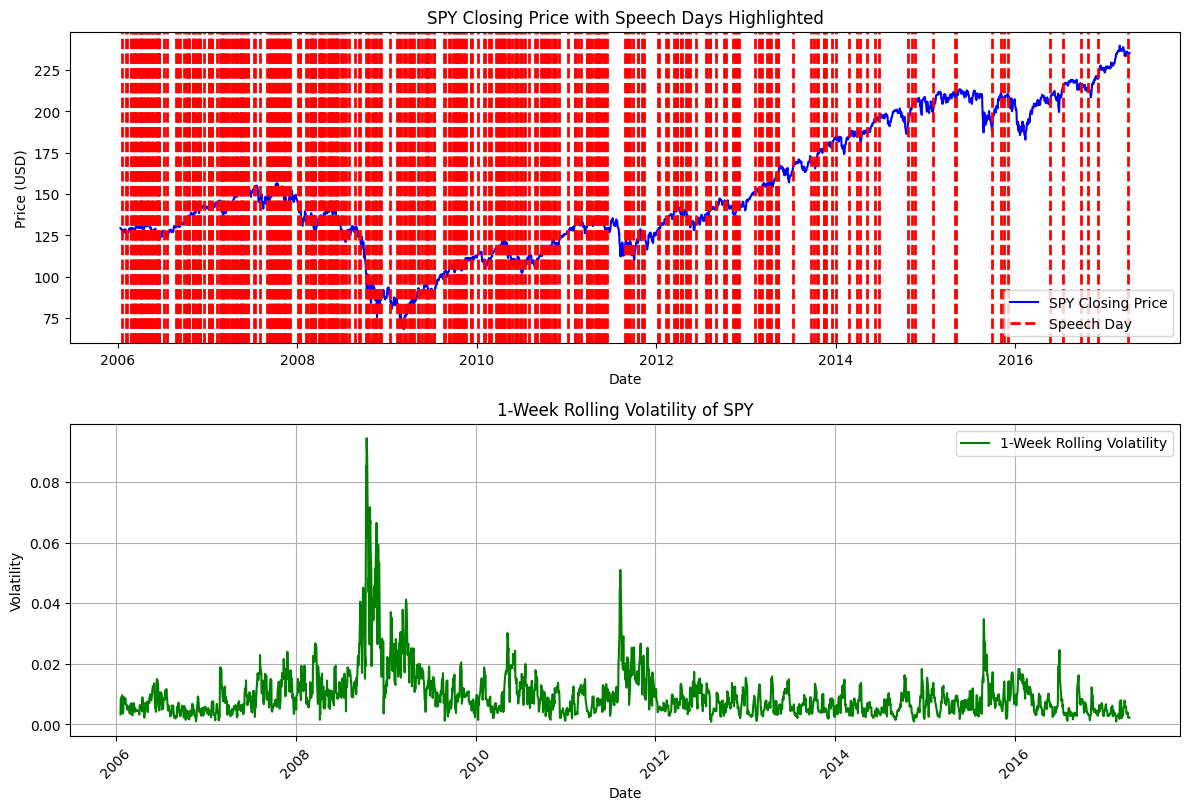

In [98]:
import matplotlib.pyplot as plt

# Plotting the SPY data
plt.figure(figsize=(12, 8))

# Plot the SPY closing price
plt.subplot(2, 1, 1)  # Top subplot
plt.plot(spy_data.index, spy_data['Close'], label="SPY Closing Price", color='blue')

# Highlighting the speech days with vertical lines
for speech_day in spy_data[spy_data['is_speech_day']].index:
    plt.axvline(x=speech_day, color='red', linestyle='--',label="Speech Day" if speech_day == spy_data[spy_data['is_speech_day']].index[0] else "")

# Adding labels and title to the first subplot
plt.title("SPY Closing Price with Speech Days Highlighted")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

# Plotting the 1-week rolling volatility
plt.subplot(2, 1, 2)  # Bottom subplot
plt.plot(spy_data.index, spy_data['rolling_volatility'], label="1-Week Rolling Volatility", color='green')

# Adding labels and title to the second subplot
plt.title("1-Week Rolling Volatility of SPY")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()

# Show the plot
plt.tight_layout()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
